<a href="https://colab.research.google.com/github/DhruviPunamia15/Dhruvi-Punamia_LP_Synapse26/blob/week1_ML/DhruviPunamia_Copy_of_Synapse_Task1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week One**

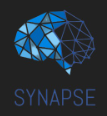

In the previous task, we explored Regression and understood how Machine Learning models can be used to predict continuous values. Now, let's take a step further and explore Classification using the K-Nearest Neighbours algorithm.

In this task, we will work with a classification dataset, perform the necessary preprocessing, standardize our features, and train a K-Nearest Neighbours classifier. We will also evaluate our model and explore how choosing different values of K affects its performance.

Like before, resources and comments are provided above each cell. Peruse the resources, understand what is happening, and then get coding. Let's get started.

# Classification

#### In the below cells, we are going to implement K Nearest Neighbour Classification.

Link to the dataset is here - https://drive.google.com/file/d/1bVOfBJYUr0JtZ7pp1lcyNamnHHXn_fDm/view?usp=sharing <br>

Import the 'classified_data.txt' dataset using pandas and print the first five columns.

Use "index_col" parameter to index the dataframe according to the first column. Otherwise, a new column would get created. Call this new dataframe 'df'.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/classified_data.txt", index_col=0)

df.head(20)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1
5,0.833928,1.523302,1.104743,1.021139,1.107377,1.010930,1.279538,1.280677,0.510350,1.528044,0
6,0.944705,1.251761,1.074885,0.286473,0.996440,0.428860,0.910805,0.755305,1.111800,1.110842,0
7,0.816174,1.088392,0.895343,0.243860,0.943123,1.045131,1.146536,1.341886,1.225324,1.425784,0
8,0.776551,1.463812,0.783825,0.337278,0.742215,1.072756,0.880300,1.312951,1.118165,1.225922,0
9,0.772280,0.515111,0.891596,0.940862,1.430568,0.885876,1.205231,0.596858,1.542580,0.981879,1


If you're wondering what these column names signify, well they are classified as the dataset name suggests. Our job here is to simply take the data at face value and build a model for classifying the target classes.

## Basic EDA

### In the following two cells, use info() and describe() to get the data type and statistical summary of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 93.8 KB


In [ ]:
df.describe()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


### Draw boxplots for all the features for '0' and 'TARGET CLASS'

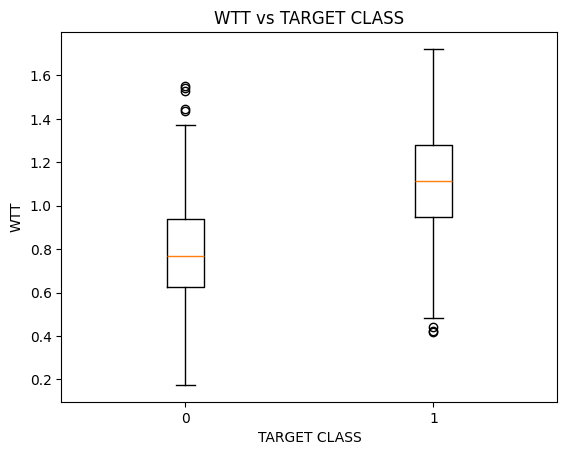

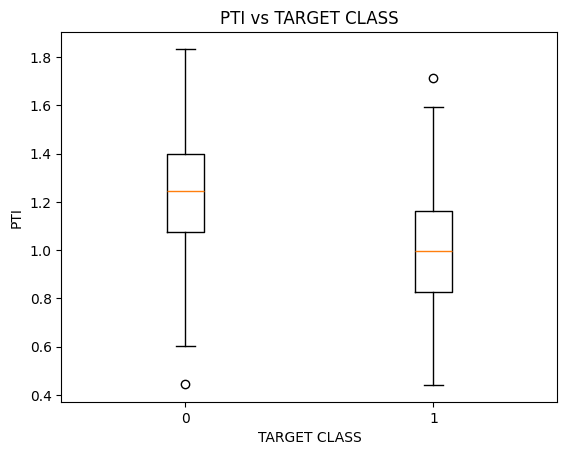

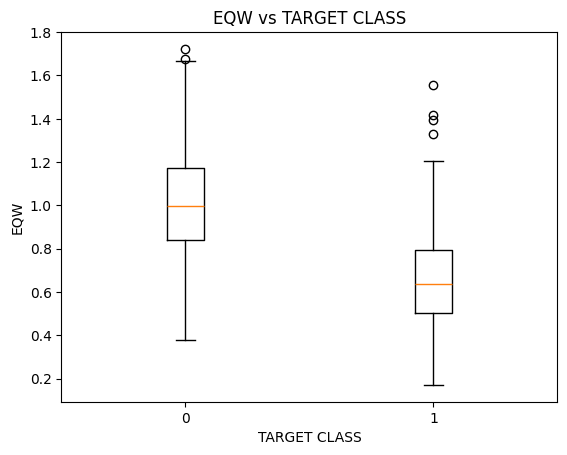

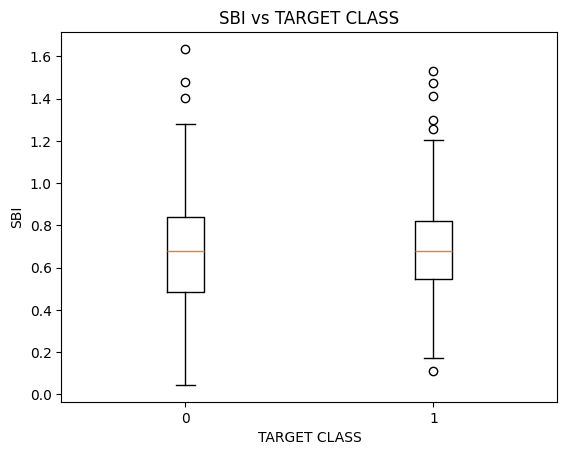

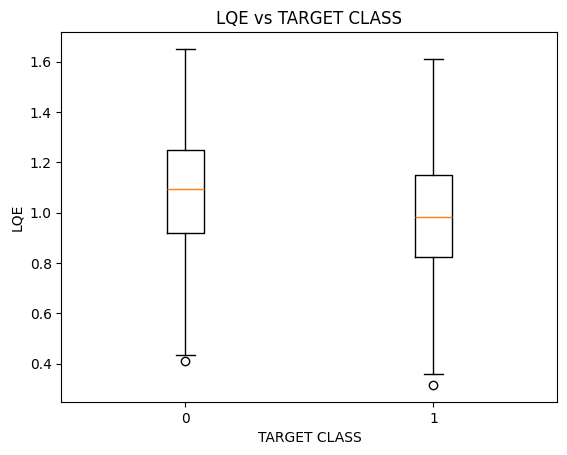

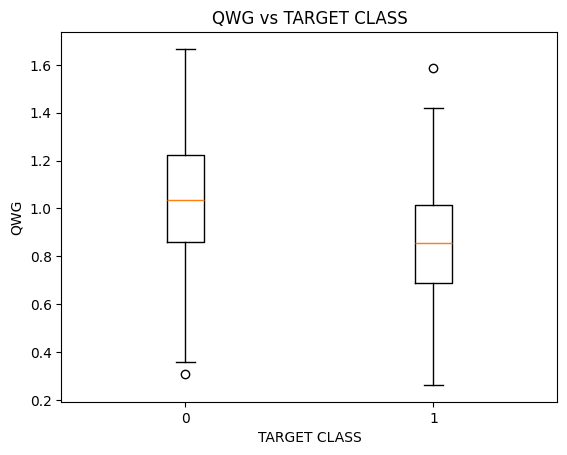

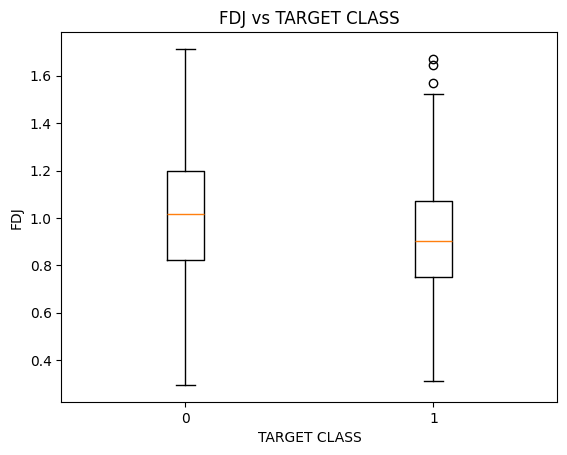

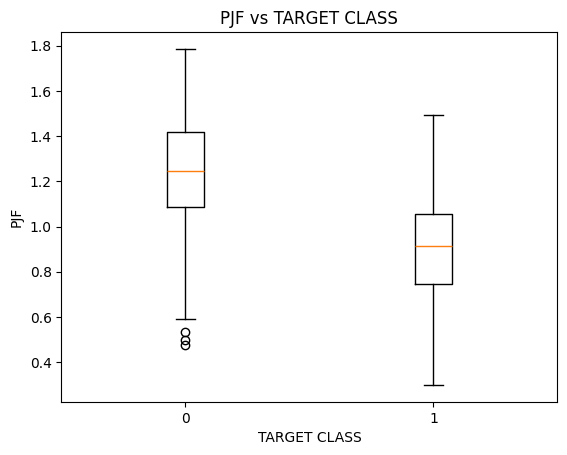

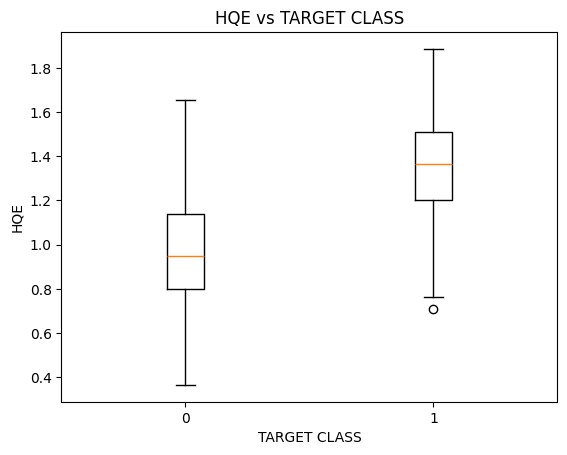

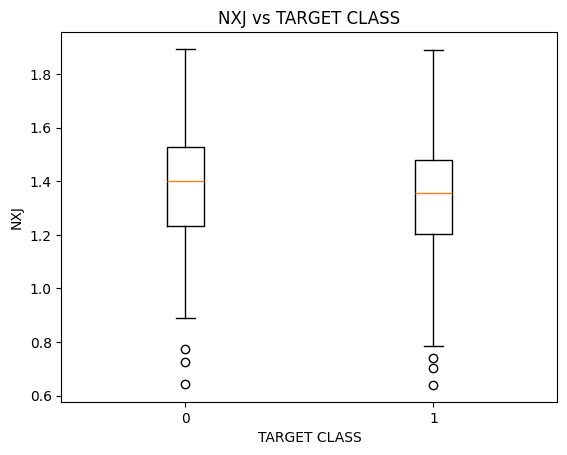

In [ ]:
features = df.columns[:-1]

for col in features:
    plt.boxplot([df[df["TARGET CLASS"]==0][col], df[df["TARGET CLASS"]==1][col]], tick_labels=["0","1"])
    plt.xlabel("TARGET CLASS")
    plt.ylabel(col)
    plt.title(col + " vs TARGET CLASS")
    plt.show()

### Question: What conclusion, if any can you draw from these boxplots?🤔
List them down below.

From these boxplots,one can figure out which columns will have more influence on the KNN classification.So features such as SBI,FDJ,NXJ,LQE,QWG show overlapping boxes hence they will not be helpful in differentiating between the target classes 0 and 1.While WTT,PTI,HQE,EQW,PJF show difference between the two classes and thus will be helpful for better classification.

### Standardize the features using sklearn.preprocessing



##### import StandardScaler from Sklearn and instantiate it to a variable called "scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

##### Fit only the features data to this scaler (leaving the TARGET CLASS column out) and then transform


In [ ]:
scaler.fit(df.drop("TARGET CLASS", axis=1))

scaled_features = scaler.transform(df.drop("TARGET CLASS", axis=1))

In [ ]:
print(scaled_features)

[[-0.12354188  0.18590747 -0.91343069 ... -1.48236813 -0.9497194
  -0.64331425]
 [-1.08483602 -0.43034845 -1.02531333 ... -0.20224031 -1.82805088
   0.63675862]
 [-0.78870217  0.33931821  0.30151137 ...  0.28570652 -0.68249379
  -0.37784986]
 ...
 [ 0.64177714 -0.51308341 -0.17920486 ... -2.36249443 -0.81426092
   0.11159651]
 [ 0.46707241 -0.98278576 -1.46519359 ... -0.03677699  0.40602453
  -0.85567   ]
 [-0.38765353 -0.59589427 -1.4313981  ... -0.56778932  0.3369971
   0.01034996]]


**scaler.transform() will return an array. We need to convert this into a dataframe. Do this and add the column names to the dataframe. Call this new dataframe as "df_feat". Call head() on this df**<br>
Note: The final dataframe will have the initial columns except the "TARGET CLASS".

In [ ]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])

df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


## Train/Test split

### Set X to be equal to df_feat and set y accordingly. As you know, X contains our training features and y contains our target.
Hint: y can be taken directly from the initial dataframe "df"

In [ ]:
X = df_feat

y = df["TARGET CLASS"]

**Import train_test_split function from scikit-learn**<br>
**Create X and y train and test splits in one command using a test size of 0.3 and a random seed**<br>
They should be called X_train, X_test, y_train, y_test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Model fit and training

Before moving ahead with the cells below, learn how the K Nearest Neighbour Algorithm actually works.

Theory and implementation : https://youtu.be/wTF6vzS9fy4 <br>
Theory: https://www.analyticsvidhya.com/blog/2018/08/k-nearest-neighbor-introduction-regression-python/

**import KNeighborsClassifier from sklearn and initialize it with neighbours = 1 (more on this later) . Fit this on X_train and y_train**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=1)

kn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

**Using this fitted model, predict on X_test. Store these predictions in variable called pred.**

In [ ]:
pred = kn.predict(X_test)

**Let us check how correct these predictions are.<br>
Print a classification report of y_test and pred**<br>
Hint: sklearn classification_report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.95      0.93      0.94       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



#### Learn all about classification metrics - https://medium.com/analytics-vidhya/evaluation-metrics-for-classification-models-e2f0d8009d69

**Print the accuracy using numpy and round it to 3 decimal places.**

In [ ]:
accuracy = np.mean(pred == y_test)
print(round(accuracy, 3))

0.937


##### Hey, not bad! But can we further improve this? Remember our arbitrary choice for n_neighbours? Can we improve that?

### Choosing optimal 'k'

**Above, we chose n_neighbours to be equal to 1. Choosing a small value of K leads to unstable decision boundaries. <br>
We need to select n_neighbours by calculating the accuracy for every value of n from 1 to 60 and then choosing the one which gives the highest accuracy.**

In [ ]:
accuracy_list = []

for K in range(1, 61):
    kn = KNeighborsClassifier(n_neighbors=K)
    kn.fit(X_train, y_train)
    pred_k = kn.predict(X_test)
    acc = np.mean(pred_k == y_test)
    accuracy_list.append(acc)


##### **Plot a graph of K value vs Accuracy**

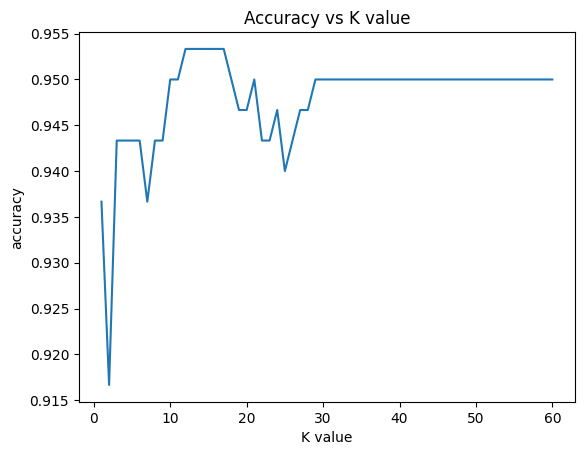

In [ ]:
plt.plot(range(1, 61), accuracy_list)
plt.xlabel("K value")
plt.ylabel("accuracy")
plt.title("Accuracy vs K value")
plt.show()

##### **Choose the best value of n_neighbours and give a reason why and also print the accuracy**

In [ ]:
best_k = accuracy_list.index(max(accuracy_list)) + 1
best_accuracy = max(accuracy_list)

print("Best K:", best_k)
print("Best Accuracy:", round(best_accuracy, 3))

Best K: 12
Best Accuracy: 0.953


Research Task: Machine Learning in Healthcare

We’ve worked with Linear Regression and KNN Classification. Now let’s see where they can actually be useful.

Domain: Healthcare

Find:

1 real-world application of Linear Regression in healthcare
1 real-world application of KNN Classification in healthcare

For each application, briefly explain what the model is being used for and how it helps solve the problem.

Try to find applications that are actually interesting rather than the most obvious examples you come across.

No implementation is required — just research and explain your findings in your own words.

Good Luck People:)

Real World Applications of Linear Regression and KNN Classification in Healthcare sector.
In simple terms,linear regression is something that helps establish
relationship between something that exists and something you want to predict using data.It can  naturally be used in may sectors to understand the unknown but from statistical data.
In Healthcare,Linear Regression is used in variety of applications as its a highly data-driven sector especially medical research in real-time today uses Linear Regression to make crucial decisions.


* The one application that stood out to me is 'Predicting the right Drug Dosage for Patients' in the hospital.One outstanding implementation of this was via Prediction of Warfarin dosage in A Korean Population.Warfarin is basically an oral blood thinner which is presribed mainly to prevent blood clots,strokes etc.The problem faced by the doctors in Korea was that the drug itself had a low therapeutic index-as in the difference between too low a dosage and too deadly of a dosage was quite thin.On top of that the obvious issue was that all human bodies are built differently and process these heavy medications differently.Initially the doctors thought of prescribing a fixed dosage of 5mg/day for all patients and then use a trial and error approach which would take weeks

* The problem that needed to be solved was of eradicating this high-risk guess game and instead accurately predict correct dosage from day 1.Now,the Multiple Regression Model that was used covered various genetic as well as clinical factors to give s single dose recommendation by dividing dataset into 90% training and 10% testing dataset.The core model looked like  $$\sqrt{\text{Weekly Warfarin Dose}} = \beta_0 + \beta_1(\text{Age}) + \beta_2(\text{Height}) + \beta_3(\text{Weight}) + \beta_4(\text{CYP2C9 Genotype}) + \beta_5(\text{VKORC1 Genotype}) + \beta_6(\text{Amiodarone Use}) + \dots$$  
 The model gave the weighed distribution of each factor of the patient on whether to add or subtract the dosage for them.Hence briefly the MLR model helped in reducing adverse drug after-effects and statistically determining a safe medical level of dosage for every patient.





For the KNN Classification,its simply based on the logic that objects or data points that are near each other will have similar characteristics.

* One of the interesting applications of this technique that I came across was
for'Thyroid disease detection'.Our thyroid gland controls crucial hormones like thyroxine and triiodothyronine and over and under supply of these hormones causes diseases like HyperThyroidism and HypoThyroidism.The medical problem was that doctors used to conduct medical blood tests for these hormone levels and prepare datasets. But these datasets had missing and raw values that were disturbing the calculations.
Hence there was a need of a CAD(Computer Aided Detection) System that could look at those blood numbers and 'classify' them as Hypothyroid,Hyperthyroid or Neutral.What the model did was fill in all the patient data,normalized all the values,adjusted the missing values and grouped the data points into respective clusters of the three categories.When a new lab result arrived the system looked for the K nearest neighbours in order to classify the numbers as a match of the closest existing data entries.Based on the distance then whichever label was most common among the neighbours was assigned to the new patient.

# ALL THE BEST!!!

End of Task

©DJS Synapse 2026 - 2027